<a href="https://colab.research.google.com/github/gabrielxbox/Formacao_Completa_Intelig-ncia_Artificial/blob/main/xai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
!pip install lime
!pip install interpret
!pip install eli5
!pip install shap


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import IPython
import numpy as np
import eli5
from eli5 import show_prediction
import shap
import lime.lime_tabular
from interpret import set_visualize_provider
from interpret.provider import InlineProvider
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show

In [24]:
credito = pd.read_csv('Credit.csv')

In [25]:
credito.shape

(1000, 21)

In [26]:
credito.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,'critical/other existing credit',radio/tv,1169,'no known savings',>=7,4,'male single',none,...,'real estate',67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,'existing paid',radio/tv,5951,<100,1<=X<4,2,'female div/dep/mar',none,...,'real estate',22,none,own,1,skilled,1,none,yes,bad
2,'no checking',12,'critical/other existing credit',education,2096,<100,4<=X<7,2,'male single',none,...,'real estate',49,none,own,1,'unskilled resident',2,none,yes,good
3,<0,42,'existing paid',furniture/equipment,7882,<100,4<=X<7,2,'male single',guarantor,...,'life insurance',45,none,'for free',1,skilled,2,none,yes,good
4,<0,24,'delayed previously','new car',4870,<100,1<=X<4,3,'male single',none,...,'no known property',53,none,'for free',2,skilled,2,none,yes,bad


In [27]:
previsores = credito.iloc[:,0:-1].values
classe = credito.iloc[:,-1].values

In [28]:
labelEncoder = LabelEncoder()
for i in range(previsores.shape[1]):
  if previsores[:,i].dtype == 'object':
    previsores[:,i] = labelEncoder.fit_transform(previsores[:,i])

In [29]:
classe = labelEncoder.fit_transform(classe)

In [30]:
X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(previsores, classe, test_size=0.3)

In [31]:
modelo = RandomForestClassifier(n_estimators=100)
modelo.fit(X_treinamento, y_treinamento)

RandomForestClassifier()

Lime

In [32]:
expl = lime.lime_tabular.LimeTabularExplainer(X_treinamento, feature_names=list(credito)[0:20], class_names="class")
prever = lambda x: modelo.predict_proba(x).astype(float)
#
exp = expl.explain_instance(X_teste[0], prever, num_features=5)
exp.show_in_notebook(show_all=True)
#

Eli5

In [34]:
eli5.show_weights(modelo, feature_names=list(credito)[0:20])
#

Weight,Feature
0.1454 ± 0.0674,credit_amount
0.1078 ± 0.0567,age
0.1030 ± 0.0634,duration
0.0962 ± 0.0620,checking_status
0.0682 ± 0.0432,purpose
0.0632 ± 0.0521,credit_history
0.0490 ± 0.0395,employment
0.0490 ± 0.0393,savings_status
0.0424 ± 0.0341,residence_since
0.0406 ± 0.0338,property_magnitude


In [35]:
previsores[1]

array([1, 29, 3, 7, 770, 3, 0, 1, 0, 2, 1, 2, 3, 1, 1, 0, 3, 0, 0, 1],
      dtype=object)

In [38]:
eli5.show_prediction(modelo, previsores[1], feature_names=list(credito)[0:20], show_feature_values=True)
#

shap

In [41]:
explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_teste)

abs_shap_values = np.abs(shap_values)
impotancia_geral = np.mean(np.mean(abs_shap_values, axis=2), axis=0)
print(impotancia_geral)

[0.08441536 0.03835985 0.02606945 0.02494684 0.03273255 0.02082008
 0.00910581 0.01133599 0.01292036 0.00454645 0.00661445 0.01243185
 0.02745073 0.0171246  0.01874821 0.00465952 0.00507888 0.00326993
 0.00500551 0.00187392]


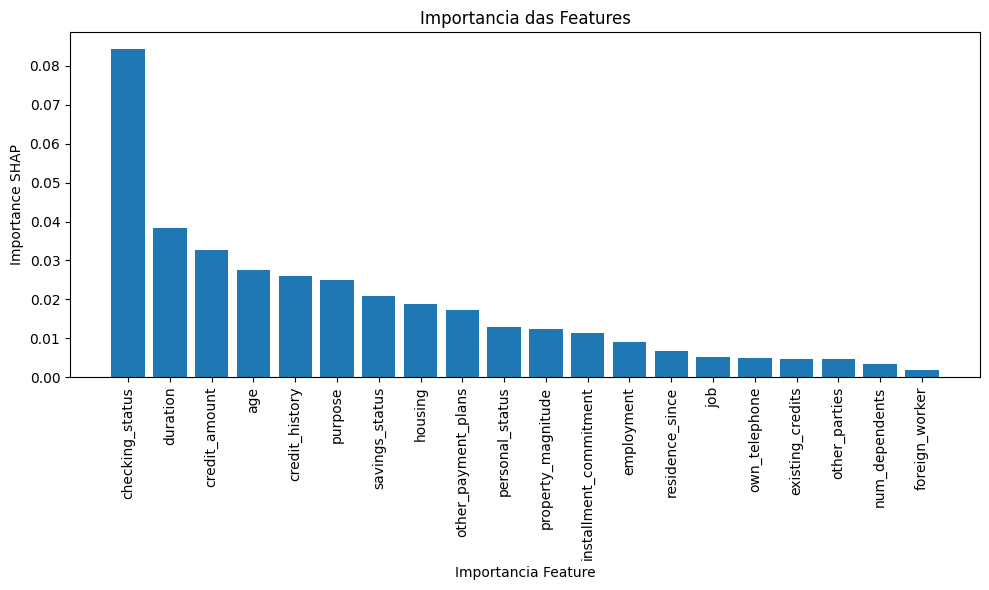

In [43]:
importancia_df = pd.DataFrame({
  'Feature': credito.columns[0:-1],
  'Importance': impotancia_geral
}).sort_values(by='Importance', ascending=False)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.bar(importancia_df['Feature'],
        height=importancia_df['Importance'])
plt.xticks(rotation=90)
plt.ylabel('Importance SHAP')
plt.xlabel('Importancia Feature')
plt.title('Importancia das Features')
plt.tight_layout()
plt.show()

Interprat

In [44]:
set_visualize_provider(InlineProvider())
ebm = ExplainableBoostingClassifier(feature_names=list(credito)[0:20])
ebm.fit(X_treinamento, y_treinamento)
global_explanation = ebm.explain_global()
show(global_explanation)